#1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from huggingface_hub import hf_hub_download

# 2. Download Dataset

In [2]:
zip_path = hf_hub_download(
    repo_id="Ghanshyam51/image_classification",
    filename="image_classification.zip",
    repo_type="dataset"
)

print("Downloaded:", zip_path)

image_classification.zip:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

Downloaded: /root/.cache/huggingface/hub/datasets--Ghanshyam51--image_classification/snapshots/556ae90c2e820739be4fc2988380012248848e6c/image_classification.zip


#3. Extract Dataset

In [3]:
extract_path = "/content/image_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted")

Dataset Extracted


In [4]:
for root, dirs, files in os.walk("/content/image_dataset"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/image_dataset/dataset/train.csv
/content/image_dataset/dataset/test.csv


In [5]:
train_df = pd.read_csv("/content/image_dataset/dataset/train.csv")
test_df = pd.read_csv("/content/image_dataset/dataset/test.csv")

print(train_df.head())
print("Classes:", train_df['Class'].nunique())

            Image   Class
0   image7042.jpg    Food
1   image3327.jpg    misc
2  image10335.jpg  Attire
3   image8019.jpg    Food
4   image2128.jpg  Attire
Classes: 4


In [6]:
train_df['Image'] = train_df['Image'].apply(
    lambda x: f"/content/image_dataset/dataset/Train Images/{x}"
)

test_df['Image'] = test_df['Image'].apply(
    lambda x: f"/content/image_dataset/dataset/Test Images/{x}"
)


In [7]:
train_data, val_data = train_test_split(train_df,test_size=0.2,random_state=42,stratify=train_df['Class'])

In [8]:
IMG_SIZE = 128
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    train_data,
    x_col='Image',
    y_col='Class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_data,
    x_col='Image',
    y_col='Class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 4786 validated image filenames belonging to 4 classes.
Found 1197 validated image filenames belonging to 4 classes.


In [9]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model= Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [12]:
histrory=model.fit(train_generator,validation_data=val_generator,epochs=15,callbacks=[early_stop])

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 71s 684ms/step - accuracy: 0.2453 - loss: 2.0193 - val_accuracy: 0.3409 - val_loss: 1.4979
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 298ms/step - accuracy: 0.3347 - loss: 1.6221 - val_accuracy: 0.4077 - val_loss: 1.3597
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 280ms/step - accuracy: 0.3909 - loss: 1.4908 - val_accuracy: 0.4703 - val_loss: 1.2648
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 296ms/step - accuracy: 0.4313 - loss: 1.3700 - val_accuracy: 0.5013 - val_loss: 1.1912
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.4593 - loss: 1.2894 - val_accuracy: 0.5263 - val_loss: 1.1264
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.4860 - loss: 1.2290 - val_accuracy: 0.5522 - val_loss: 1.0750
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 293ms/step - accuracy: 0.5259 - loss: 1.1524 - val_accuracy: 0.5698 - val_loss: 1.0389
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 292ms/step - accuracy: 0.5493 - loss: 1.1074 - val_accu

In [13]:
base_model = model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 55s 510ms/step - accuracy: 0.5905 - loss: 0.9989 - val_accuracy: 0.6750 - val_loss: 0.8817
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 292ms/step - accuracy: 0.6540 - loss: 0.8855 - val_accuracy: 0.6892 - val_loss: 0.8355
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 300ms/step - accuracy: 0.6749 - loss: 0.8302 - val_accuracy: 0.7043 - val_loss: 0.8062
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 296ms/step - accuracy: 0.6862 - loss: 0.7887 - val_accuracy: 0.7084 - val_loss: 0.7822
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - accuracy: 0.7229 - loss: 0.7293 - val_accuracy: 0.7151 - val_loss: 0.7734
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 284ms/step - accuracy: 0.7252 - loss: 0.7101 - val_accuracy: 0.7193 - val_loss: 0.7564
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 291ms/step - accuracy: 0.7422 - loss: 0.6790 - val_accuracy: 0.7235 - val_loss: 0.7492
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.7534 - loss: 0.6524 - val_accu

In [16]:
loss, accuracy =model.evaluate(val_generator)
print(accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7485 - loss: 0.6969
0.7485380172729492


In [17]:
model.save("image_classification_mobilenetv2.h5")

In [18]:
model.save("image_classification_mobilenetv2.keras")

In [19]:
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

print("Uploaded Image:", img_path)

Saving OIP.jpg to OIP.jpg
Uploaded Image: OIP.jpg


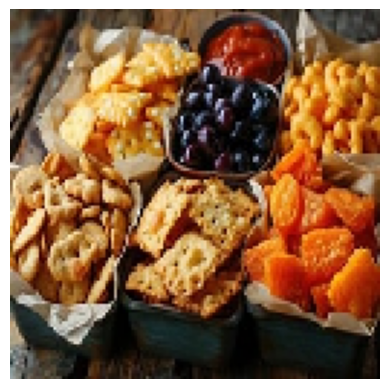

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction : Food
Confidence : 93.31%


In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Load Model
model = load_model("image_classification_mobilenetv2.keras")

# Class Names
class_names = [
    "Attire",
    "Decorationandsignage",
    "Food",
    "misc"
]

# Show Image
img = image.load_img(img_path, target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
pred = model.predict(img_array)

pred_class = np.argmax(pred)
confidence = np.max(pred)

print("Prediction :", class_names[pred_class])
print("Confidence :", f"{confidence*100:.2f}%")
